# Wigner-Smith Time-Delay Matrix

Computes the **Wigner-Smith time-delay matrix** $Q = -i S^{-1} \partial S / \partial \omega$
for a slab of dielectric cylinders.

**What this example demonstrates:**
1. Computing $\partial S / \partial \lambda$ via finite differences
2. Converting to $\partial S / \partial \omega$ using the chain rule: $\partial S/\partial\omega = -(\lambda^2 / 2\pi c) \cdot \partial S/\partial\lambda$
3. Forming $Q = -i S^{-1} \partial S / \partial \omega$
4. Extracting proper delay times (eigenvalues of $Q$)

In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "1"
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import sys
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd, inv, eig

sys.path.insert(0, '../..')

from Scattering_Code.smatrix_parameters import smatrix_parameters
from Scattering_Code.jax.smatrix import smatrix

In [2]:
WAVELENGTH = 0.93
PERIOD     = 12.81
RADIUS     = 0.25
N_CYL_REF  = 1.3
MU         = 1.0
CMMAX      = 5
PHIINC     = np.pi / 2
Eva_TOL    = 1e-2
NUM_CYL    = 10
SEED       = 42
C_LIGHT    = 1.0  # natural units where c = 1

n_prop = int(np.floor(PERIOD / WAVELENGTH))
n_eva  = max(int(np.floor(
    PERIOD / (2*np.pi) * np.sqrt(
        (np.log(Eva_TOL) / (2*RADIUS))**2 + (2*np.pi/WAVELENGTH)**2
    )
)) - n_prop, 0)
nmax = n_prop + n_eva
nm   = 2 * nmax + 1

## 1. Setup and Compute Baseline S-Matrix

In [3]:
spacing = 2.5 * RADIUS
cyls_per_row = int(PERIOD / spacing)
rows_needed = NUM_CYL / cyls_per_row + 2
thickness = round(max(0.5, rows_needed * spacing * 1.5), 1)

rng = np.random.RandomState(SEED)
margin = RADIUS * 1.5
min_sep = 2.5 * RADIUS
clocs = np.zeros((NUM_CYL, 2))
for i in range(NUM_CYL):
    for _ in range(10000):
        x = margin + rng.rand() * (PERIOD - 2*margin)
        y = margin + rng.rand() * (thickness - 2*margin)
        if i == 0 or np.all(np.sqrt((x - clocs[:i, 0])**2 + (y - clocs[:i, 1])**2) > min_sep):
            clocs[i] = [x, y]
            break

cmmaxs = np.full(NUM_CYL, CMMAX, dtype=int)
cepmus = np.column_stack([np.full(NUM_CYL, N_CYL_REF**2), np.full(NUM_CYL, MU)])
crads  = np.full(NUM_CYL, RADIUS)

sp = smatrix_parameters(WAVELENGTH, PERIOD, PHIINC,
                        1e-11, 1e-4, 5, 3, 1000, 3, 5, 1, PERIOD/120)

print("Computing S(lambda)...")
S0, _ = smatrix(clocs, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH, nmax, thickness, sp, 'On')
S0 = np.array(S0)
                

# Truncate to propagating modes
p = slice(n_eva, nm - n_eva) if n_eva > 0 else slice(None)
if n_eva > 0:
    S_trunc = np.block([
        [S0[p, p],          S0[p, nm+n_eva:2*nm-n_eva]],
        [S0[nm+n_eva:2*nm-n_eva, p], S0[nm+n_eva:2*nm-n_eva, nm+n_eva:2*nm-n_eva]]
    ])
else:
    S_trunc = S0

print(f"S truncated to {S_trunc.shape}")

Computing S(lambda)...
  Computing T-Matrix...


W0417 23:13:38.770488 12416088 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


  transall: 45 pairs (43 spectral, 2 spatial)
  T-Matrix: 10.9s
  Solving linear system...
  Solve: 1.3s
  Computing S11 & S21...
  S11&S21: 0.8s
  Computing S12 & S22...
  S12&S22: 0.1s
  Total: 13.7s (0.2 min)
S truncated to (54, 54)


## 2. Compute $\partial S / \partial \lambda$ via Finite Differences

In [4]:
h = 1e-6

sp_p = smatrix_parameters(WAVELENGTH+h, PERIOD, PHIINC,
                          1e-11, 1e-4, 5, 3, 1000, 3, 5, 1, PERIOD/120)
sp_m = smatrix_parameters(WAVELENGTH-h, PERIOD, PHIINC,
                          1e-11, 1e-4, 5, 3, 1000, 3, 5, 1, PERIOD/120)

Sp, _ = smatrix(clocs, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH+h,
                nmax, thickness, sp_p, 'On')
Sp = np.array(Sp)
Sm, _ = smatrix(clocs, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH-h,
                nmax, thickness, sp_m, 'On')
Sm = np.array(Sm)


if n_eva > 0:
    Sp_t = np.block([[Sp[p, p], Sp[p, nm+n_eva:2*nm-n_eva]],
                     [Sp[nm+n_eva:2*nm-n_eva, p], Sp[nm+n_eva:2*nm-n_eva, nm+n_eva:2*nm-n_eva]]])
    Sm_t = np.block([[Sm[p, p], Sm[p, nm+n_eva:2*nm-n_eva]],
                     [Sm[nm+n_eva:2*nm-n_eva, p], Sm[nm+n_eva:2*nm-n_eva, nm+n_eva:2*nm-n_eva]]])
else:
    Sp_t = Sp
    Sm_t = Sm

dS_dlam = (Sp_t - Sm_t) / (2*h)
print(f"||dS/dlambda|| = {np.linalg.norm(dS_dlam):.4f}")

  Computing T-Matrix...
  transall: 45 pairs (43 spectral, 2 spatial)
  T-Matrix: 6.4s
  Solving linear system...
  Solve: 0.0s
  Computing S11 & S21...
  S11&S21: 0.0s
  Computing S12 & S22...
  S12&S22: 0.0s
  Total: 6.5s (0.1 min)
  Computing T-Matrix...
  transall: 45 pairs (43 spectral, 2 spatial)
  T-Matrix: 6.0s
  Solving linear system...
  Solve: 0.0s
  Computing S11 & S21...
  S11&S21: 0.0s
  Computing S12 & S22...
  S12&S22: 0.0s
  Total: 6.1s (0.1 min)
||dS/dlambda|| = 526.0858


## 3. Convert to $\partial S / \partial \omega$ and Form Q

$\omega = 2\pi c / \lambda$, so $\partial S / \partial \omega = -(\lambda^2 / 2\pi c) \cdot \partial S / \partial \lambda$

In [5]:
dS_domega = -(WAVELENGTH**2 / (2 * np.pi * C_LIGHT)) * dS_dlam

# Wigner-Smith matrix
Q = -1j * inv(S_trunc) @ dS_domega

# Delay times = eigenvalues of Q
delay_times = np.sort(np.real(eig(Q)[0]))[::-1]

print(f"Number of delay times: {len(delay_times)}")
print(f"Max delay time: {delay_times[0]:.4f}")
print(f"Min delay time: {delay_times[-1]:.4f}")

Number of delay times: 54
Max delay time: -1.7931
Min delay time: -50.6498


## 4. Plot Delay Times

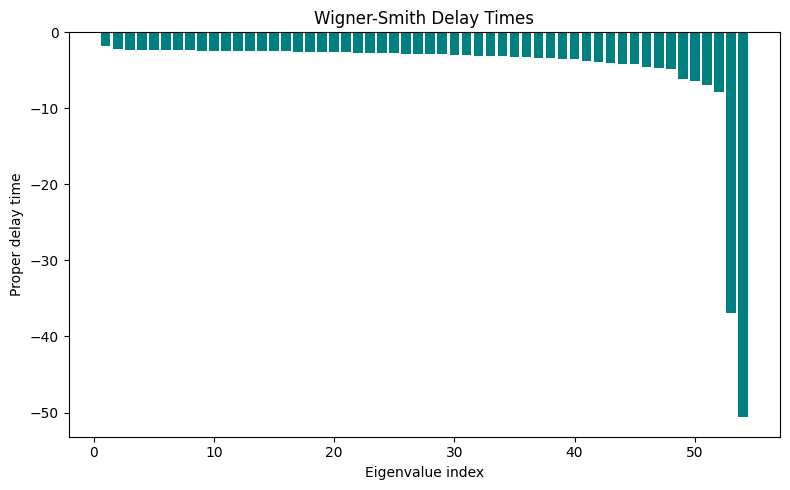

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(1, len(delay_times)+1), delay_times, color='teal')
ax.set_xlabel('Eigenvalue index')
ax.set_ylabel('Proper delay time')
ax.set_title('Wigner-Smith Delay Times')
ax.axhline(0, color='gray', ls='--', lw=0.5)
plt.tight_layout()
plt.savefig('wigner_smith_delay_times.png', dpi=150)
plt.show()